# EMG - analiza sygnału
Lena Borówka

In [14]:
#importy bibliotek
import os
import numpy as np
import pandas as pd
import scipy.signal as signal
import scipy.integrate
import matplotlib.pyplot as plt

#ładowanie danych z pliku CSV
emg1 = pd.read_csv("emgMVC.csv", usecols=['elapsed_seconds', 'voltage'])
emg2_butelka = pd.read_csv("emg-rma-1-butelka.csv", usecols=['elapsed_seconds', 'voltage'])
emg2_ksiazka = pd.read_csv("emg-rma-2-ksiazka.csv", usecols=['elapsed_seconds', 'voltage'])
emg2_but = pd.read_csv("emg-rma-3-but.csv", usecols=['elapsed_seconds', 'voltage'])
emg3 = pd.read_csv("emgfatigue.csv", usecols=['elapsed_seconds', 'voltage'])

# Opis Doświadczenia
Celem ćwiczenia była rejestracja i cyfrowa analiza powierzchniowego sygnału elektromiograficznego (sEMG) mięśnia dwugłowego ramienia (biceps brachii) w trzech scenariuszach eksperymentalnych.

Układ pomiarowy: 

Pomiary przeprowadzono za pomocą jednokanałowego układu do akwizycji potencjałów bioelektrycznych, próbkującego z częstotliwością 2000 Hz. Dwie elektrody powierzchniowe naklejono na brzuścu mięśnia zgodnie z instrukcją, a elektrodę referencyjną umieszczono na nadgarstku.

Procedura eksperymentalna:

Eksperyment 1 (MVC): Wyznaczono maksymalny skurcz izometryczny (Maximum Voluntary Contraction). Wykonano trzy próby maksymalnego napięcia bicepsa przeciwko stałemu oporowi (próba podniesienia łóżka). Każdy skurcz trwał około 10 sekund, po czym następowała przerwa na odpoczynek.

Eksperyment 2 (Wpływ obciążenia na aktywację): Zarejestrowano sygnał podczas unoszenia trzech przedmiotów różniących się masą i wymuszających inny rodzaj chwytu: bidonu (ok. 1,1 kg), książek (ok. 3,2 kg) oraz buta (ok. 0,4 kg). Pozwoliło to na wyznaczenie względnej aktywacji mięśnia (% MVC) dla każdego z wariantów.

Eksperyment 3 (Analiza zmęczenia): Przeprowadzono próbę długotrwałego skurczu izometrycznego ze stałym obciążeniem. Zarejestrowany sygnał podzielono na trzy równe, 10-sekundowe etapy czasowe. Dla każdego z nich wyznaczono medianę częstotliwości (MDF), aby zaobserwować zmiany w widmie mocy sygnału wynikające ze zmęczenia mięśnia.

In [15]:
#konfiguracja parametrów - przydadzą się w przyszłych funkcjach


# Częstotliwość próbkowania
fs = 2000

# Parametry filtru pasmowo-przepustowego 
BANDPASS_LOW = 20     # [Hz] - usuwa artefakty ruchowe
BANDPASS_HIGH = 450   # [Hz] - usuwa szum wysokoczęstotliwościowy

#częstotliwość do filtru notch - odcięcie szumu sieciowego
NOTCH_FREQ = 50


# Częstotliwość odcięcia filtru dolnoprzepustowego tworzącego obwiednię (envelope)
# - dla MVC sygnał jest "spokojniejszy" więc użyto niższej wartości
ENV_CUTOFF_MVC = 10     
ENV_CUTOFF_OTHER = 4   

# Parametry detekcji skurczów 

BURST_THRESHOLD_RATIO = 0.1   # próg = baseline + ratio * (max - baseline)
BURST_MIN_DURATION_S = 0.3     # minimalna długość skurczu [s] (dla MVC/obciążeń)
BURST_MIN_DURATION_FATIGUE_S = 2.5   # minimalna długość skurczu [s] dla zmęczenia 
BURST_MERGE_GAP_S = 4        # scalanie segmentów bliższych niż ten odstęp [s]
BURST_BASELINE_S = 1       


In [16]:
# Funkcje użyte w dalszych częściach analizy

def offset(emg):
    """Usuwa offset sygnału EMG poprzez odjęcie wartości średniej."""
    return emg - np.mean(emg)

def notch_filter(emg, fs, freq=NOTCH_FREQ, q=30):
    """
    Filtr zaporow usuwający zakłócenia sieciowe (50Hz).

    """
    nyq = fs / 2
    if freq >= nyq:
        return emg  # częstotliwość notch poza zakresem Nyquista - pomiń
    b, a = scipy.signal.iirnotch(freq, q, fs)
    return scipy.signal.filtfilt(b, a, emg)

def bandpass_filter(emg, fs, low=BANDPASS_LOW, high=BANDPASS_HIGH, order=4):
    """
    Filtr pasmowo-przepustowy Butterwortha. 
    Usuwa artefakty ruchowe (niskie częstotliwości) oraz szum wysokoczęstotliwościowy.
    """
    nyq = fs / 2
    high_eff = min(high, nyq * 0.98)   # zabezpieczenie przed przekroczeniem Nyquista
    low_eff = max(low, 0.5)
    b, a = scipy.signal.butter(order, [low_eff / nyq, high_eff / nyq], btype="bandpass")
    return scipy.signal.filtfilt(b, a, emg)

def rectify(emg):
    """Prostowanie sygnału (wartość bezwzględna) - zamienia wartości ujemne na dodatnie."""
    return np.abs(emg)

def linear_envelope(emg_rectified, fs, cutoff=1.0, order=4):
    """
    Funkcja tworząca obwiednię
    """
  
    window_duration = 0.15  
    window_samples = int(window_duration * fs)
    
    window = np.ones(window_samples) / window_samples
    rms_envelope = np.sqrt(np.convolve(emg_rectified**2, window, mode='same'))
    
    # 3. KOREKTA AMPLITUDY 
    """ Obwiednia daje zaniżoną amplitudę więc zastosowano korektę """
    scaling_factor = 2.2
    return rms_envelope * scaling_factor
    return envelope

def filteremg(emg, fs, env_cutoff=1.0, low=BANDPASS_LOW, high=BANDPASS_HIGH):
    """
    Pełen łańcuch standardowego przetwarzania surowego sygnału EMG:
        1) filtr notch 
        2) filtr pasmowo-przepustowy 
        3) prostowanie (rectification)
        4) obwiednia (envelope) - filtr dolnoprzepustowy sygnału wyprostowanego

    Zwraca: (sygnał_po_filtracji_pasmowej, obwiednia)
    """
    sig = notch_filter(emg, fs) 
    sig = bandpass_filter(sig, fs, low, high)
    rect = rectify(sig)
    env = linear_envelope(rect, fs, env_cutoff)
    return sig, env

def detect_bursts(envelope, fs, expected_bursts=None,
                   threshold_ratio=BURST_THRESHOLD_RATIO,
                   min_duration_s=BURST_MIN_DURATION_S,
                   merge_gap_s=BURST_MERGE_GAP_S,
                   baseline_s=BURST_BASELINE_S):
    """
    Wykrywa początki i końce skurczów mięśnia (bursts) na podstawie obwiedni EMG.

    Metoda:
      1. Poziom bazowy (szum spoczynkowy) szacowany jest jako średnia z pierwszych
         `baseline_s` sekund sygnału (zakładamy, że na początku nagrania mięsień
         jest rozluźniony).
      2. Próg detekcji = poziom_bazowy + threshold_ratio * (max(obwiednia) - poziom_bazowy)
      3. Segmenty obwiedni powyżej progu, oddzielone krótkimi przerwami
         (< merge_gap_s), są scalane w jeden skurcz.
      4. Segmenty krótsze niż min_duration_s są odrzucane jako szum/artefakt.


    """
    baseline_samples = int(baseline_s * fs)
    if baseline_samples < len(envelope) and baseline_samples > 0:
        baseline_level = np.mean(envelope[:baseline_samples])
    else:
        baseline_level = np.percentile(envelope, 10)

    threshold = baseline_level + threshold_ratio * (np.max(envelope) - baseline_level)

    above = envelope > threshold
    diff = np.diff(above.astype(int))
    starts = np.where(diff == 1)[0] + 1
    ends = np.where(diff == -1)[0] + 1
    if above[0]:
        starts = np.insert(starts, 0, 0)
    if above[-1]:
        ends = np.append(ends, len(above))

    segments = list(zip(starts.tolist(), ends.tolist()))

    # scalanie segmentów rozdzielonych krótką przerwą
    merge_gap = int(merge_gap_s * fs)
    merged = []
    for seg in segments:
        if merged and seg[0] - merged[-1][1] <= merge_gap:
            merged[-1][1] = seg[1]
        else:
            merged.append([seg[0], seg[1]])

    # odrzucenie zbyt krótkich segmentów (szum)
    min_len = int(min_duration_s * fs)
    bursts = [(s, e) for s, e in merged if (e - s) >= min_len]

    if expected_bursts is not None and len(bursts) != expected_bursts:
        print(f"    UWAGA: wykryto {len(bursts)} skurcz(ów), oczekiwano {expected_bursts}. "
              f"Jeśli wynik jest błędny, dostrój BURST_THRESHOLD_RATIO / "
              f"BURST_MIN_DURATION_S w sekcji KONFIGURACJA.")

    return bursts, threshold


def get_power_spectrum(segment, fs):
    """
    Widmo mocy sygnału metodą periodogramu (oparte na FFT).
    """
    freqs, power = scipy.signal.periodogram(segment, fs)
    return power, freqs


def smooth_spectrum(power, cutoff=5, pseudo_fs=1000):
    """
    Wygładza widmo mocy filtrem dolnoprzepustowym Butterwortha
    """
    nyq = pseudo_fs / 2
    b, a = scipy.signal.butter(4, cutoff / nyq, btype="lowpass")
    return scipy.signal.filtfilt(b, a, power)


def median_frequency(freqs, power):
    """
    Wyznacza Medianę Częstotliwości (Median Frequency, MDF) - częstotliwość
    dzielącą pole pod widmem mocy na dwie równe połowy. Spadek MDF w czasie
    jest klasycznym wskaźnikiem narastającego zmęczenia mięśnia.
    """
    area = scipy.integrate.cumulative_trapezoid(power, freqs, initial=0)
    half_area = area[-1] / 2
    idx_candidates = np.where(area >= half_area)[0]
    idx = idx_candidates[0] if len(idx_candidates) > 0 else len(freqs) - 1
    return freqs[idx]



Funkcje użyte w ramach wizualizacji:

In [17]:
def plot_raw(t, emg, title,):
    plt.figure(figsize=(11, 4))
    plt.plot(t, emg, linewidth=0.6, color="steelblue")
    plt.title(title)
    plt.xlabel("t / s")
    plt.ylabel("Voltage, V")
    plt.grid(alpha=0.3)
    plt.show()

def plot_envelope_with_bursts(t, envelope, bursts, threshold, title, ylabel, fname,
                               raw_signal=None):
    plt.figure(figsize=(11, 4))
    if raw_signal is not None:
        plt.plot(t, raw_signal, linewidth=0.4, color="lightgray", label="Sygnał po filtracji pasmowej")
    plt.plot(t, envelope, linewidth=1.2, color="darkorange", label="Obwiednia")
    for i, (s, e) in enumerate(bursts):
        plt.axvspan(t[s], t[min(e, len(t) - 1)], color="green", alpha=0.2,
                    label="Wykryty skurcz" if i == 0 else None)
    plt.axhline(threshold, color="red", linestyle="--", linewidth=0.8, label="Próg detekcji")
    plt.title(title)
    plt.xlabel("t / s")
    plt.ylabel(ylabel)
    plt.legend(loc="upper right")
    plt.grid(alpha=0.3)
    plt.show()


Część pierwsza: określenie MVC

In [18]:

def analyze_mvc(emg):
    """
    Eksperyment 1 - MVC (Maximum Voluntary Contraction).
    Plik zawiera 3 skurcze (podnoszenie stołu ręką, 3x z przerwami).
    Zwraca: mean_mvc (średnia amplituda obwiedni z 3 skurczów) - wartość referencyjna
    do normalizacji w Eksperymencie 2.
    """
    print("\n=== EKSPERYMENT 1: MVC (podnoszenie stołu ręką) ===")
    t = emg1['elapsed_seconds'].values
    v_surowe = emg1['voltage'].values
    # --- 5. Wizualizacja sygnału surowego ---
    plot_raw(t, v_surowe, "Eksperyment 1: surowy sygnał EMG (MVC)")
    #usunięcie offsetu
    emg_centered = offset(v_surowe)
    #zastosowanie filtrów i obwiednia
    mvc_filt, mvc_env = filteremg(emg_centered, fs=2000)


    #  Detekcja skurczów
    bursts, threshold = detect_bursts(mvc_env, fs, expected_bursts=3)
    plot_envelope_with_bursts(
        t, mvc_env, bursts, threshold,
        "Eksperyment 1: obwiednia EMG i wykryte skurcze (MVC)",
        "Amplituda obwiedni / a.u.", "02_mvc_envelope_bursts.png",
        raw_signal=mvc_filt
    )


    mean_per_burst = [np.mean(mvc_env[s:e]) for s, e in bursts]
    mean_mvc = float(np.mean(mean_per_burst))

    for i, val in enumerate(mean_per_burst, start=1):
        print(f"  Skurcz {i}: średnia amplituda obwiedni = {val:.2f} a.u.")
    print(f"  >>> Średnie MVC (z {len(bursts)} skurczów) = {mean_mvc:.2f} a.u.")

    return mean_mvc




=== EKSPERYMENT 1: MVC (podnoszenie stołu ręką) ===


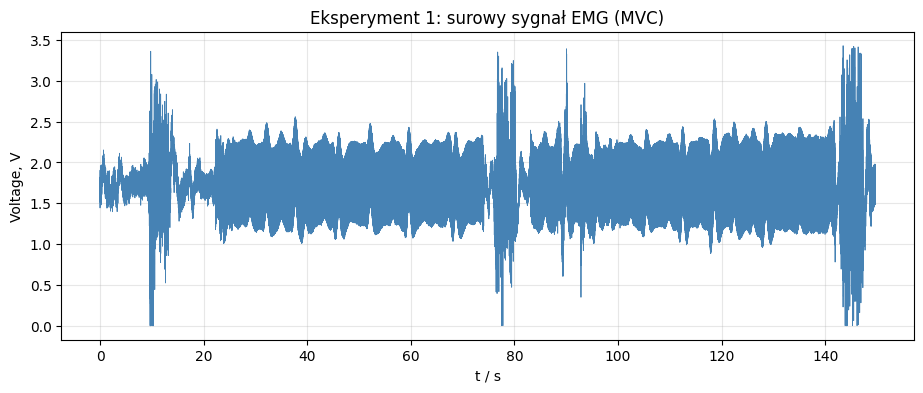

    UWAGA: wykryto 4 skurcz(ów), oczekiwano 3. Jeśli wynik jest błędny, dostrój BURST_THRESHOLD_RATIO / BURST_MIN_DURATION_S w sekcji KONFIGURACJA.


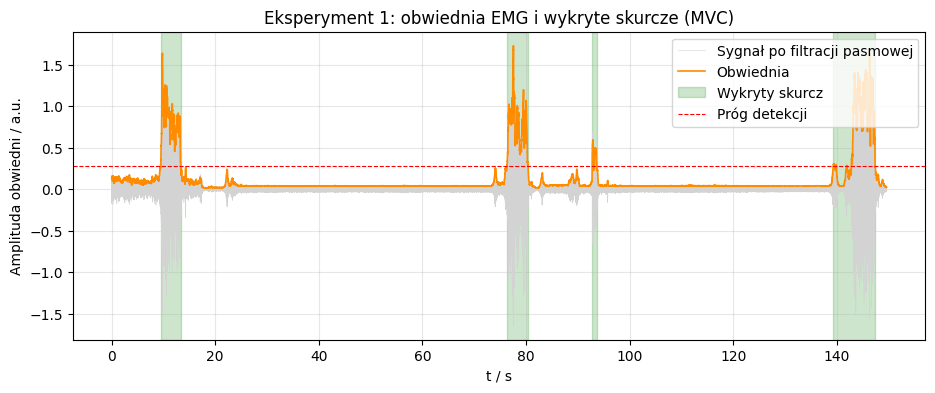

  Skurcz 1: średnia amplituda obwiedni = 0.85 a.u.
  Skurcz 2: średnia amplituda obwiedni = 0.80 a.u.
  Skurcz 3: średnia amplituda obwiedni = 0.41 a.u.
  Skurcz 4: średnia amplituda obwiedni = 0.64 a.u.
  >>> Średnie MVC (z 4 skurczów) = 0.67 a.u.


In [19]:
mean_mvc =analyze_mvc(emg1)

Część trzecia: analiza zmęczenia mięśnia

In [20]:
def analyze_fatigue(emg_dataframe, fs=2000.0):
    """
    Eksperyment 3 - analiza zmęczenia mięśnia.
    """
    print("\n=== EKSPERYMENT 3: analiza zmęczenia mięśnia ===")
    
    t = emg_dataframe['elapsed_seconds'].values
    emg = emg_dataframe['voltage'].values
    plot_raw(t, emg, "Eksperyment 3: surowy sygnał EMG (zmęczenie)")

    emg_centered = emg - emg.mean() 
    fatigue_filt, fatigue_env = filteremg(emg_centered, fs, env_cutoff=ENV_CUTOFF_OTHER)

    bursts, threshold = detect_bursts(
        fatigue_env, fs, expected_bursts=3,
        min_duration_s=BURST_MIN_DURATION_FATIGUE_S
    )
    
    plot_envelope_with_bursts(
        t, fatigue_env, bursts, threshold,
        "Eksperyment 3: obwiednia EMG i wykryte skurcze",
        "Amplituda obwiedni / a.u.", "07_fatigue_envelope_bursts.png",
        raw_signal=fatigue_filt
    )

    colors = ["blue", "red", "green"]
    raw_spectra = []
    
    plt.figure(figsize=(10, 5))
    for i, (s, e) in enumerate(bursts):
        segment = fatigue_filt[s:e]
        power, freqs = get_power_spectrum(segment, fs)
        raw_spectra.append((power, freqs))
        plt.plot(freqs, power, label=f"Etap {i + 1}", color=colors[i], linewidth=0.8)
    
    plt.title("Widmo mocy sygnału zmęczeniowego (surowe)")
    plt.xlabel("Częstotliwość [Hz]")
    plt.ylabel("Moc")
    plt.xlim(0, BANDPASS_HIGH)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    median_freqs = []
    plt.figure(figsize=(10, 5))
    for i, (power, freqs) in enumerate(raw_spectra):
        power_smooth = smooth_spectrum(power)
        mdf = median_frequency(freqs, power_smooth)
        median_freqs.append(mdf)
        
        plt.plot(freqs, power_smooth, label=f"Etap {i + 1} (MDF={mdf:.1f} Hz)", color=colors[i])
        plt.axvline(mdf, color=colors[i], linestyle=":", linewidth=1)
        
    plt.title("Wygładzone widmo mocy z zaznaczoną Medianą Częstotliwości (MDF)")
    plt.xlabel("Częstotliwość [Hz]")
    plt.ylabel("Moc (wygładzona)")
    plt.xlim(0, BANDPASS_HIGH)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    # Czyste logowanie wyników
    for i, mdf in enumerate(median_freqs, start=1):
        print(f"  Etap {i}: Mediana Częstotliwości (MDF) = {mdf:.2f} Hz")
        
    drop_pct = (median_freqs[0] - median_freqs[-1]) / median_freqs[0] * 100
    print(f"  >>> Spadek MDF między Etapem 1 a ostatnim etapem: {drop_pct:.1f}%")

    return median_freqs



=== EKSPERYMENT 3: analiza zmęczenia mięśnia ===


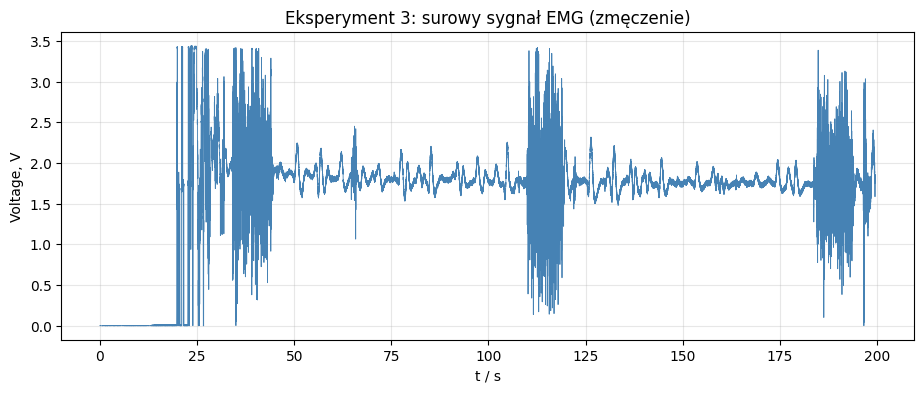

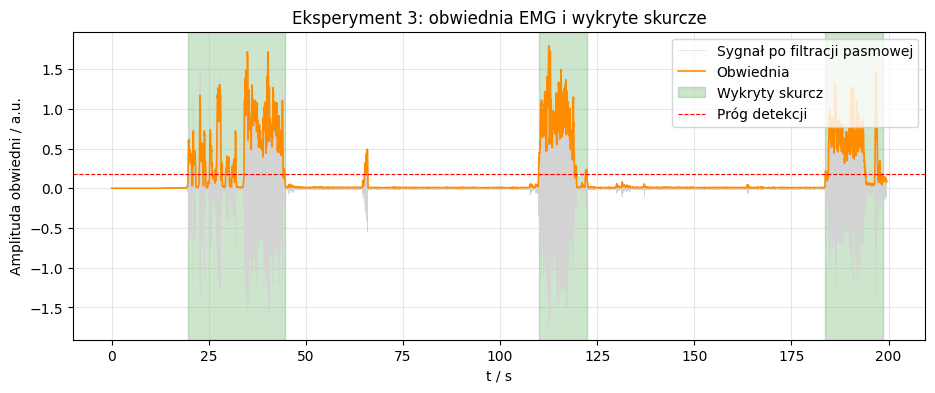

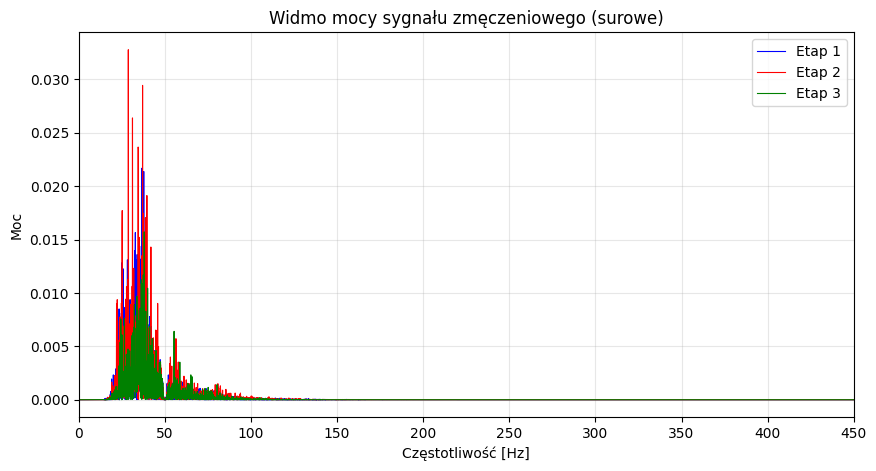

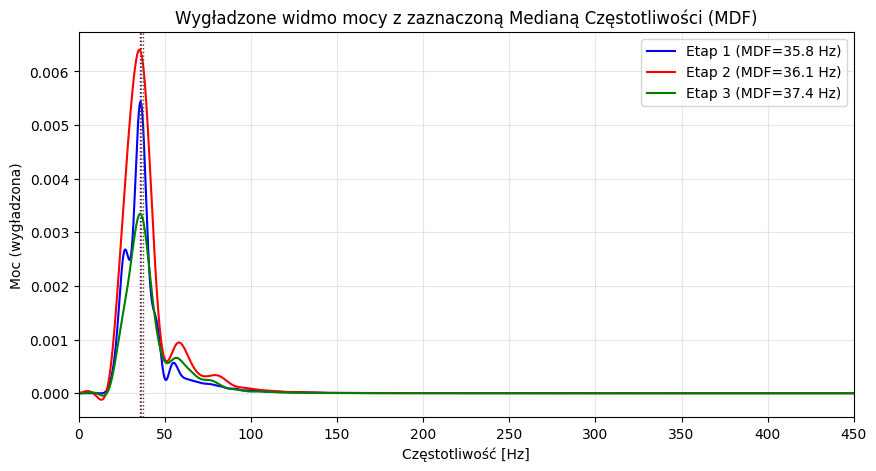

  Etap 1: Mediana Częstotliwości (MDF) = 35.83 Hz
  Etap 2: Mediana Częstotliwości (MDF) = 36.08 Hz
  Etap 3: Mediana Częstotliwości (MDF) = 37.39 Hz
  >>> Spadek MDF między Etapem 1 a ostatnim etapem: -4.4%


In [21]:
mdf_results = analyze_fatigue(emg3, fs=2000.0)

Część druga: analiza podnoszenia różnych ciężarów

In [22]:
def analyze_weights(weights_dataframes, mean_mvc, fs=2000.0):
    """
    Eksperyment 2 - analiza podnoszenia różnych ciężarów.
    """
    print("\n=== EKSPERYMENT 2: analiza podnoszenia różnych ciężarów ===")
    load_percentages = []
    
    for idx, df in enumerate(weights_dataframes):
        print(f" Przetwarzanie obciążenia nr {idx + 1}...")
        
        t = df['elapsed_seconds'].values
        emg = df['voltage'].values
        emg_centered = emg - emg.mean()
        
        filt_sig, env_sig = filteremg(emg_centered, fs, env_cutoff=1.0)
        plot_raw(t, emg, f"Obciążenie {idx + 1}: surowy sygnał")
        
        bursts, threshold = detect_bursts(env_sig, fs) 
        
        # Bezpośrednie liczenie - wiemy, że skurcze tam są
        burst_means = [np.mean(env_sig[s:e]) for s, e in bursts]
        mean_env_for_weight = np.mean(burst_means)
            
        pct_mvc = (mean_env_for_weight / mean_mvc) * 100
        load_percentages.append(pct_mvc)
        
        print(f"   Średnia amplituda obwiedni: {mean_env_for_weight:.4f} a.u.")
        print(f"   Aktywacja mięśnia względem MVC: {pct_mvc:.2f}%")
        
    return load_percentages



=== EKSPERYMENT 2: analiza podnoszenia różnych ciężarów ===
 Przetwarzanie obciążenia nr 1...


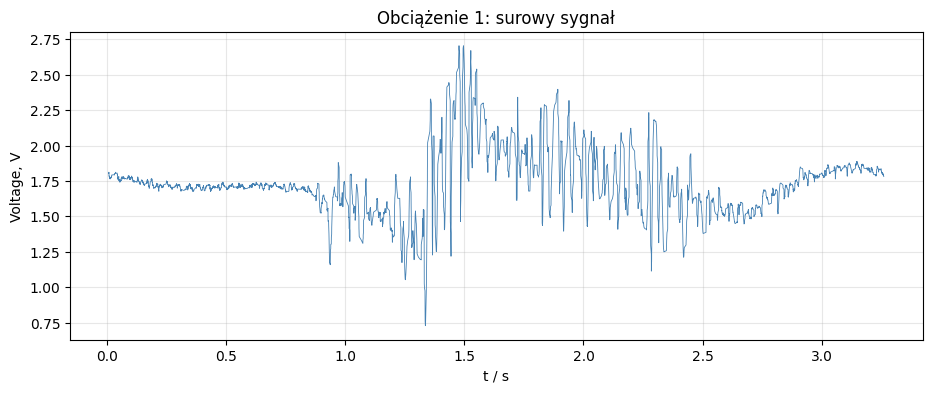

   Średnia amplituda obwiedni: 0.3637 a.u.
   Aktywacja mięśnia względem MVC: 54.07%
 Przetwarzanie obciążenia nr 2...


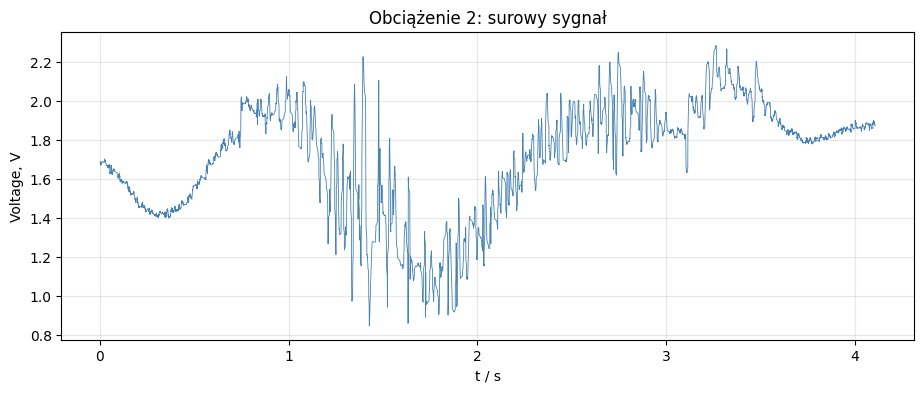

   Średnia amplituda obwiedni: 0.2112 a.u.
   Aktywacja mięśnia względem MVC: 31.39%
 Przetwarzanie obciążenia nr 3...


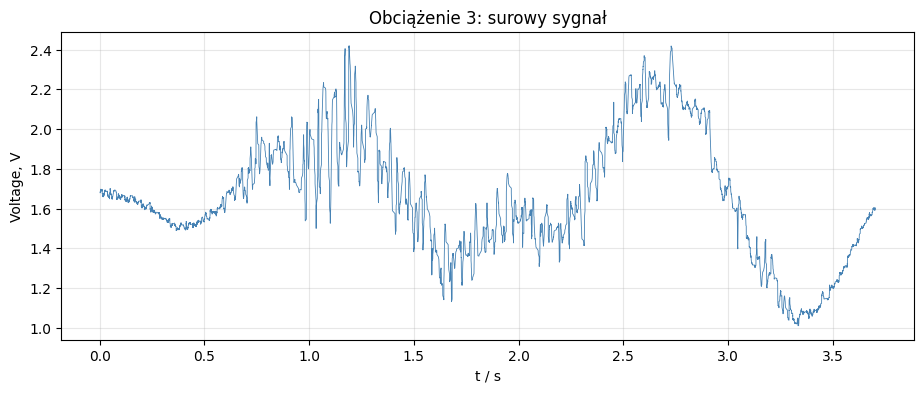

   Średnia amplituda obwiedni: 0.1705 a.u.
   Aktywacja mięśnia względem MVC: 25.34%


In [23]:
lista_ciezarow = [emg2_butelka, emg2_ksiazka, emg2_but]
wyniki_rma = analyze_weights(lista_ciezarow, mean_mvc=mean_mvc, fs=2000.0)

# Dyskusja wyników
W eksperymencie 2 (wpływ obciążenia na aktywację mięśnia) jako 100% MVC przyjęto wyliczoną średnią 0,67 a.u. Wyniki dla poszczególnych ciężarów ukształtowały się następująco:

1. Bidon (ok. 1,1 kg): 54,07% MVC

2. Książki (ok. 3,2 kg): 31,39% MVC

3. But (ok. 0,4 kg): 25,34% MVC

Na pierwszy rzut oka widać brak liniowej zależności między masą a aktywacją bicepsa – najcięższe książki wywołały mniejsze napięcie niż dużo lżejszy bidon. Wynika to z różnicy w chwycie. Książki są nieporęczne, więc przy ich podnoszeniu główną pracę wykonały mięśnie zginacze palców i przedramienia, a biceps służył jedynie jako stabilizator ruchu. Bidon z kolei wymusił chwyt cylindryczny i bezpośrednią pracę mięśnia dwugłowego ramienia. Dodatkowo seria z książkami była wykonywana jako jedna z ostatnich – pot obniżył lokalną impedancję skóry i osłabił klej na elektrodach, co mogło sztucznie zaniżyć rejestrowaną amplitudę.

W eksperymencie 3 (analiza zmęczenia) sprawdzano przesunięcie mediany częstotliwości (MDF). Wyniki dla kolejnych 10-sekundowych etapów to: 35,83 Hz, 36,08 Hz oraz 37,39 Hz.

Zamiast fizjologicznego spadku MDF (związanego z zakwaszeniem mięśnia i spadkiem prędkości przewodzenia we włóknach), zanotowano wzrost o 4,4%. Może to wynikać z dwóch czynników:

Zaszumienie sygnału: Wyjściowe wartości rzędu 35-37 Hz są bardzo niskie jak na biceps (standardowo to 60–90 Hz). Oznacza to zanieczyszczenie sygnału mocnymi artefaktami niskoczęstotliwościowymi (pływanie linii bazy, ruchy kabli, przesuwanie się wilgotnych elektrod), które zaniżyły punkt ciężkości widma.

Krótki czas próby: 10 sekund na etap to stosunkowo mało. Aby utrzymać siłę skurczu przy powoli męczących się włóknach, układ nerwowy mógł zrekrutować nowe jednostki motoryczne o wyższej częstotliwości wyładowań, co chwilowo zawyżyło parametr MDF.

# Wnioski końcowe
Zastosowana filtracja (pasmowoprzepustowa 20–450 Hz i filtr Notch 50 Hz) wyczyściła sygnał z zakłóceń sieciowych, ale przy pomiarach polowych nie da się całkowicie wyeliminować wolnozmiennych artefaktów ruchowych.

Wykorzystanie RMS do wyznaczenia obwiedni sygnału sprawdziło się bardzo dobrze – pozwoliło uniezależnić analizę i detekcję skurczów od losowych, pojedynczych szpilek napięcia.

Zarejestrowana aktywacja mięśnia (% MVC) nie jest bezpośrednio proporcjonalna do podnoszonej masy. Zależy w dużej mierze od ergonomii przedmiotu i zaangażowania mięśni pomocniczych.

Długotrwałe pomiary przy wysokiej temperaturze skutkują odklejaniem się elektrod i zmianą parametrów skóry, co drastycznie utrudnia klasyczną analizę zmęczeniową opartą na zmianach widma (MDF).
